# deterministic vs. stochastic strategy comparison

`scripts/run_optimizer.py` already runs this comparison from the command line: build a pit strategy that assumes the race stays green start to finish, build a second one that hedges against a realistic spread of sampled safety-car scenarios, then judge both plans on a held-out scenario set that neither optimization step ever saw. The script prints the two means and throws away the per-scenario numbers behind them. This notebook calls the same `run()` function directly for a couple of real circuits and keeps the per-scenario cost arrays around so their distributions -- not just the two averages -- can actually be looked at.

In [1]:
import sys
sys.path.insert(0, "..")

from pathlib import Path

import matplotlib.pyplot as plt

from scripts import run_optimizer

# real circuit/era/race-length combinations, checked against
# data/processed/schedule.parquet and laps.parquet directly rather than guessed:
# monaco ran 78 laps every 2018-2021 aero-era race but 2022 (a shortened restart), and baku has run a
# steady 51 laps in every recorded season
CASES = [
    ("monaco", "2018-2021 aero", 78),
    ("baku", "2018-2021 aero", 51),
]

PROCESSED_DIR = Path("../data/processed")

results = {
    circuit_id: run_optimizer.run(
        PROCESSED_DIR, circuit_id=circuit_id, era=era, race_length=race_length, n_scenarios=200, seed=0
    )
    for circuit_id, era, race_length in CASES
}

for circuit_id, era, race_length in CASES:
    print(f"{circuit_id}: {era}, {race_length} laps")

monaco: 2018-2021 aero, 78 laps
baku: 2018-2021 aero, 51 laps


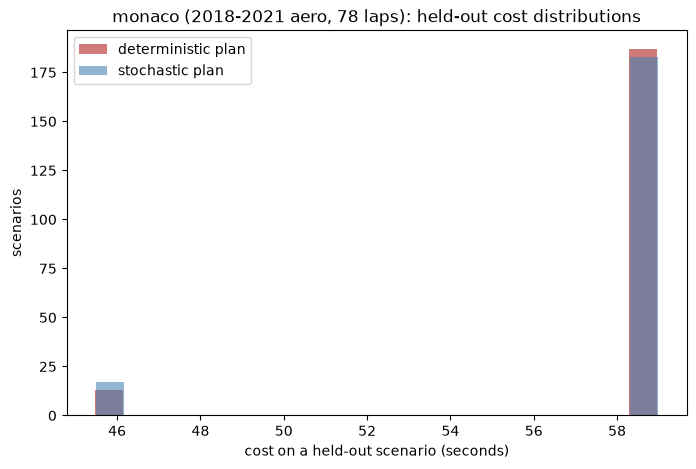

deterministic compounds ['SOFT', 'MEDIUM'], stint lengths [40, 38]
stochastic compounds ['SOFT', 'MEDIUM'], stint lengths [39, 39]
On held-out scenarios: deterministic 58.08s vs. stochastic 57.84s (gap +0.24s ± 0.19s)
No meaningful difference between the two plans on held-out scenarios at this circuit.



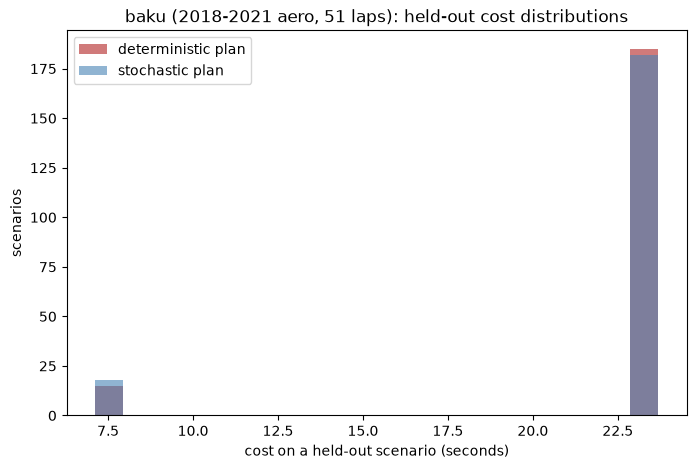

deterministic compounds ['SOFT', 'MEDIUM'], stint lengths [48, 3]
stochastic compounds ['SOFT', 'MEDIUM'], stint lengths [30, 21]
On held-out scenarios: deterministic 22.45s vs. stochastic 22.20s (gap +0.25s ± 0.48s)
No meaningful difference between the two plans on held-out scenarios at this circuit.



In [2]:
for circuit_id, era, race_length in CASES:
    result = results[circuit_id]
    deterministic_costs = result["deterministic_costs"]
    stochastic_costs = result["stochastic_costs"]

    fig, ax = plt.subplots(figsize=(8, 5))
    bins = 20
    ax.hist(deterministic_costs, bins=bins, alpha=0.6, label="deterministic plan", color="firebrick")
    ax.hist(stochastic_costs, bins=bins, alpha=0.6, label="stochastic plan", color="steelblue")
    ax.set_xlabel("cost on a held-out scenario (seconds)")
    ax.set_ylabel("scenarios")
    ax.set_title(f"{circuit_id} ({era}, {race_length} laps): held-out cost distributions")
    ax.legend()
    plt.show()

    print(f"deterministic compounds {result['deterministic']['compounds']}, "
          f"stint lengths {result['deterministic']['stint_lengths']}")
    print(f"stochastic compounds {result['stochastic']['compounds']}, "
          f"stint lengths {result['stochastic']['stint_lengths']}")

    # same held-out comparison main() prints, reusing its own significance threshold
    # rather than picking a new one here
    gap = result["deterministic_evaluated_on_scenarios"] - result["stochastic_evaluated_on_scenarios"]
    gap_se = result["gap_standard_error"]
    print(f"On held-out scenarios: deterministic {result['deterministic_evaluated_on_scenarios']:.2f}s vs. "
          f"stochastic {result['stochastic_evaluated_on_scenarios']:.2f}s (gap {gap:+.2f}s ± {gap_se:.2f}s)")
    if abs(gap) <= run_optimizer.GAP_SIGNIFICANCE_MULTIPLIER * gap_se:
        print("No meaningful difference between the two plans on held-out scenarios at this circuit.")
    elif gap > 0:
        print(f"Deterministic plan costs {gap:.2f}s more on average across held-out scenarios -- hedging paid off here.")
    else:
        print(f"The hedge cost {-gap:.2f}s more on average across held-out scenarios -- wasn't worth it here.")
    print()

Both circuits push the stochastic plan toward a noticeably different stint split than the deterministic one. At Baku the no-safety-car plan wants to run the opening stint almost to lap 48 before pitting once, while the plan that hedges against safety cars splits closer to the middle of the race, around lap 30 -- a real, fairly large change in when it pits. At Monaco the difference is milder, a lap or so either way. But at both circuits the held-out cost gap between the two plans stays inside the same 2-standard-error band `run_optimizer.py` already uses to call a result meaningful: a few tenths of a second against a standard error of a similar size. So hedging changes the plan quite a bit at these two circuits, it just doesn't move the held-out cost by more than sampling noise would explain on its own -- at least not at this scenario count. That's not a case for throwing the comparison out; it matches what the CLI script itself prints when pointed at these circuits, and it's a reasonable outcome given how close these two candidate compound sequences already are in raw pace once pit-lane time is folded in. A circuit with a much more lopsided hazard rate, or a longer scenario sample, might separate the two plans more clearly -- this notebook doesn't try to cherry-pick for that.